In [1]:
import dynamiqs as dq
import jax.numpy as jnp
from jax import jit, vmap
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from cmaes import SepCMA

In [2]:
# ============================================================
# These are fixed at fabrication — cannot be tuned online
# ============================================================
na = 15   # Hilbert space dimension for cavity (photon mode a)
nb = 5    # Hilbert space dimension for buffer mode b
ka = 0.1  # kappa_a: single photon loss rate [MHz]
kb = 10.0 # kappa_b: buffer decay rate [MHz] — large = good adiabatic elimination

# Nominal control parameters (starting point)
g_2_nom   = 1.0 + 0j  # two-photon coupling [MHz], complex
eps_d_nom = 4.0 + 0j  # buffer drive amplitude [MHz], complex

In [3]:
def make_operators():
    """
    Build annihilation operators for the two-mode system.
    a acts on cavity (na levels), b acts on buffer (nb levels).
    They are embedded in the joint Hilbert space na x nb via tensor products.
    """
    a = dq.tensor(dq.destroy(na), dq.eye(nb))
    b = dq.tensor(dq.eye(na), dq.destroy(nb))
    return a, b

In [14]:
def measure_lifetime_custom(initial_state, tfinal, kappa_a, kappa_b, 
                             eps_d, g_2, ntimes=100):
    """
    Simulate the cat qubit evolution under the Lindblad master equation.
    
    Parameters:
    - initial_state: one of "+z", "-z", "+x", "-x", "+y", "-y"
    - tfinal: simulation end time [µs]
    - kappa_a, kappa_b: loss rates [MHz]
    - eps_d, g_2: complex control parameters
    - ntimes: number of time points to save
    
    Returns: dynamiqs result with expects[0]=<sx>, expects[1]=<sz>
    """
    a, b = make_operators()
    
    # Derived parameters from adiabatic elimination of buffer
    eps_2      = 2 * g_2 * eps_d / kappa_b        # effective two-photon drive
    kappa_2    = 4 * jnp.abs(g_2)**2 / kappa_b    # effective two-photon dissipation
    cat_argument = 2 / kappa_2 * (eps_2 - kappa_a / 4)
    
    if cat_argument <= 0:
        raise ValueError(
            f"Unphysical parameters: cat_argument={float(cat_argument):.4f}. "
            f"Single photon loss too strong relative to two-photon drive."
        )
    
    alpha_estimate = jnp.sqrt(cat_argument)  # estimated cat size |α|
    
    # Hamiltonian: two-photon exchange + buffer drive
    # g2* a a b† + g2 a† a† b — two photon exchange between cavity and buffer
    # -eps_d b† - eps_d* b   — coherent drive on buffer
    H = (jnp.conj(g_2) * a @ a @ b.dag()
         + g_2 * a.dag() @ a.dag() @ b
         - eps_d * b.dag()
         - jnp.conj(eps_d) * b)
    
    # Jump operators (dissipation)
    loss_b = jnp.sqrt(kappa_b) * b  # buffer decay (fast, stabilizes cat)
    loss_a = jnp.sqrt(kappa_a) * a  # cavity photon loss (slow, causes errors)
    
    tsave = jnp.linspace(0, tfinal, ntimes)
    
    # Logical basis states built from coherent states |±α⟩
    g_state = dq.coherent(na, alpha_estimate)   # |+α⟩ = logical |0⟩
    e_state = dq.coherent(na, -alpha_estimate)  # |-α⟩ = logical |1⟩
    
    basis = {
        "+z": g_state,
        "-z": e_state,
        "+x": (g_state + e_state) / jnp.sqrt(2),  # even cat
        "-x": (g_state - e_state) / jnp.sqrt(2),  # odd cat
        "+y": (g_state + 1j * e_state) / jnp.sqrt(2),
        "-y": (g_state - 1j * e_state) / jnp.sqrt(2),
    }
    
    # Logical observables
    # sx = parity operator = exp(iπ a†a): easy to measure experimentally
    sx = (1j * jnp.pi * a.dag() @ a).expm()
    # sz = |+z><+z| - |-z><-z|: bit value, requires knowledge of α
    sz = basis["+z"] @ basis["+z"].dag() - basis["-z"] @ basis["-z"].dag()
    sz = dq.tensor(sz, dq.eye(nb))
    
    psi0 = dq.tensor(basis[initial_state], dq.fock(nb, 0))
    
    res = dq.mesolve(
        H, [loss_b, loss_a], psi0, tsave,
        options=dq.Options(progress_meter=False),
        exp_ops=[sx, sz]
    )
    return res

In [15]:
def model(p, t):
    """Exponential decay model: A * exp(-t/tau) + C"""
    A, tau, C = p
    return A * jnp.exp(-t / tau) + C

def residuals(p, x, y):
    return model(p, x) - y

def robust_exp_fit(x, y):
    """
    Fit an exponential decay to data (x, y).
    Uses robust soft_l1 loss to handle outliers.
    Returns the fitted parameters and curve.
    """
    A0   = float(y.max() - y.min())
    C0   = float(y.min())
    tau0 = float(x.max() - x.min())
    p0   = [A0, tau0, C0]
    
    res = least_squares(
        residuals, p0,
        args=(x, y),
        bounds=([0, 0, -jnp.inf], [jnp.inf, jnp.inf, jnp.inf]),
        loss="soft_l1",
        f_scale=0.1
    )
    return {"popt": res.x, "y_fit": model(res.x, x)}

Computing baseline lifetimes...
Tx  = 1.3000 µs
Tz  = 4558.07 µs
η   = 3506.3


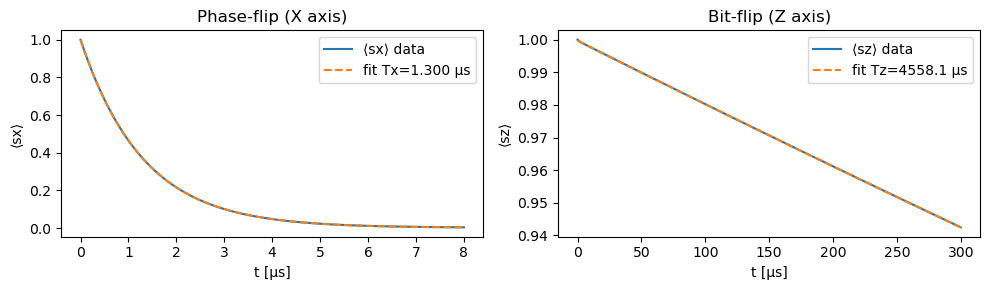

In [20]:
def compute_baseline(kappa_a, kappa_b, g_2, eps_d):
    """
    Run full exponential fit to extract Tx, Tz, and eta at nominal parameters.
    This is done ONCE offline before the optimizer starts.
    It gives us:
    - The reference lifetimes to compare against during optimization
    - The reference eta to use as optimization target
    """
    print("Computing baseline lifetimes...")
    
    # Choose tfinal long enough to see the decay:
    # tfinalx ~ 5 * Tx,  tfinalz ~ 0.1 * Tz (Tz is very long)
    tfinalx = 8.0    # µs — captures full Tx decay
    tfinalz = 300.0  # µs — captures beginning of Tz decay (enough for fit)
    
    tsave_x = jnp.linspace(0, tfinalx, 100)
    tsave_z = jnp.linspace(0, tfinalz, 100)
    
    res_x = measure_lifetime_custom("+x", tfinalx, kappa_a, kappa_b, eps_d, g_2)
    res_z = measure_lifetime_custom("+z", tfinalz, kappa_a, kappa_b, eps_d, g_2)
    
    fit_x = robust_exp_fit(tsave_x, res_x.expects[0].real)
    fit_z = robust_exp_fit(tsave_z, res_z.expects[1].real)
    
    Tx = fit_x["popt"][1]
    Tz = fit_z["popt"][1]
    eta = Tz / Tx
    
    print(f"Tx  = {Tx:.4f} µs")
    print(f"Tz  = {Tz:.2f} µs")
    print(f"η   = {eta:.1f}")
    
    # Plot the fits to verify quality
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].plot(tsave_x, res_x.expects[0].real, label="⟨sx⟩ data")
    axes[0].plot(tsave_x, fit_x["y_fit"], "--", label=f"fit Tx={Tx:.3f} µs")
    axes[0].set(xlabel="t [µs]", ylabel="⟨sx⟩", title="Phase-flip (X axis)")
    axes[0].legend()
    axes[1].plot(tsave_z, res_z.expects[1].real, label="⟨sz⟩ data")
    axes[1].plot(tsave_z, fit_z["y_fit"], "--", label=f"fit Tz={Tz:.1f} µs")
    axes[1].set(xlabel="t [µs]", ylabel="⟨sz⟩", title="Bit-flip (Z axis)")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    
    return Tx, Tz, eta

Tx_baseline, Tz_baseline, eta_baseline = compute_baseline(
    ka, kb, g_2_nom, eps_d_nom
)

In [ ]:
# ============================================================
# REWARD DESIGN: Option C (hybrid)
# ============================================================
# Key insight: Tx and Tz live on very different timescales.
# - Tx ~ 1.27 µs  → fit exactly, cheap (short simulation)
# - Tz ~ 4558 µs  → proxy via single late-time measurement
#                   (full fit would require simulating thousands of µs)
#
# Reward = w1 * Tx + w2 * sz_proxy - w3 * (eta_proxy - eta_baseline)^2
#
# - Tx: directly maximized (larger = better phase-flip protection)
# - sz_proxy: ⟨sz⟩ at t=t_probe_z, large means Tz is still long
# - eta penalty: keeps the bias ratio near the baseline value
# ============================================================

T_PROBE_Z = 500.0   # µs — fixed probe time for Tz proxy
                     # chosen << Tz_baseline so sz_proxy is still sensitive

def reward(g2, eps_d, w1=1.0, w2=1.0, w3=0.1, eps=1e-6):
    
    # --- Tx: full fit ---
    tfinalx = 8.0
    tsave_x = jnp.linspace(0, tfinalx, 20)
    res_x = measure_lifetime_custom("+x", tfinalx, ka, kb, eps_d=eps_d, g_2=g2, ntimes=10)
    Tx = robust_exp_fit(tsave_x, res_x.expects[0].real)["popt"][1]
    
    # --- Tz proxy ---
    res_z = measure_lifetime_custom("+z", T_PROBE_Z, ka, kb, eps_d=eps_d, g_2=g2, ntimes=5)
    sz_proxy = res_z.expects[1].real[-1]
    
    # --- Reward: NO eta penalty, just maximize both ---
    r = w1 * (Tx / Tx_baseline) + w2 * sz_proxy
    return r, Tx, sz_proxy


# Test at nominal
r_nom, Tx_nom, sz_nom = reward(g_2_nom, eps_d_nom)
print(f"Nominal reward : {r_nom:.4f}")
print(f"Tx             : {Tx_nom:.4f} µs")
print(f"sz_proxy       : {sz_nom:.4f}")

Nominal reward : 1.9062
Tx             : 1.3000 µs
sz_proxy       : 0.9061


In [ ]:
BATCH_SIZE = 6
N_EPOCHS   = 20

mean0 = jnp.array([
    g_2_nom.real + 0.3,    # perturbed Re(g2)
    g_2_nom.imag,          # Im(g2) = 0
    eps_d_nom.real + 0.5,  # perturbed Re(eps_d)
    eps_d_nom.imag,        # Im(eps_d) = 0
])
sigma0 = 0.2

optimizer = SepCMA(
    mean=mean0,
    sigma=sigma0,
    bounds=jnp.array([
        [0.1,  3.0],   # Re(g2)
        [-1.0, 1.0],   # Im(g2)
        [1.0,  8.0],   # Re(eps_d)
        [-1.0, 1.0],   # Im(eps_d)
    ]),
    population_size=BATCH_SIZE,
    seed=0,
)

In [25]:
mean_history       = []
reward_history     = []
reward_std_history = []
Tx_history         = []
sz_history         = []

print("Starting CMA-ES optimization...")
for epoch in range(N_EPOCHS):
    
    # Sample population
    xs = []
    for _ in range(optimizer.population_size):
        xs.append(optimizer.ask())
    xs = jnp.array(xs)
    
    # Evaluate reward for each candidate
    rewards, Txs, szs = [], [], []
    for x in xs:
        g2_try    = x[0] + 1j * x[1]
        eps_d_try = x[2] + 1j * x[3]
        try:
            r, Tx, sz = reward(g2_try, eps_d_try)
        except ValueError:
            r, Tx, sz = -1e6, 0.0, 0.0
        rewards.append(r)
        Txs.append(Tx)
        szs.append(sz)
    rewards = jnp.array(rewards)

    # CMA-ES minimizes, so negate reward
    solutions = [(xs[j], -rewards[j]) for j in range(len(xs))]
    optimizer.tell(solutions)
    
    # Log
    mean_history.append(optimizer.mean.copy())
    reward_history.append(float(jnp.mean(rewards)))
    reward_std_history.append(float(jnp.std(rewards)))
    Tx_history.append(float(jnp.mean(jnp.array(Txs))))
    sz_history.append(float(jnp.mean(jnp.array(szs))))
    
    if epoch % 10 == 0:
        m = optimizer.mean
        print(f"Epoch {epoch:3d} | "
              f"g2={m[0]:.3f}+{m[1]:.3f}j | "
              f"eps_d={m[2]:.3f}+{m[3]:.3f}j | "
              f"reward={reward_history[-1]:.4f} | "
              f"Tx={Tx_history[-1]:.4f} µs | "
              f"sz={sz_history[-1]:.4f}")

mean_history       = jnp.array(mean_history)
reward_history     = jnp.array(reward_history)
reward_std_history = jnp.array(reward_std_history)
Tx_history         = jnp.array(Tx_history)
sz_history         = jnp.array(sz_history)

Starting CMA-ES optimization...
Epoch   0 | g2=1.670+-0.041j | eps_d=4.549+0.017j | reward=2.1143 | Tx=1.6068 µs | sz=0.8783


KeyboardInterrupt: 

In [ ]:
epochs = jnp.arange(N_EPOCHS)

# --- Reward ---
plt.figure(figsize=(7, 3))
plt.plot(epochs, reward_history, label="Mean reward")
plt.fill_between(epochs,
    reward_history - reward_std_history,
    reward_history + reward_std_history,
    alpha=0.2)
plt.axhline(r_nom, linestyle="--", color="gray", label="Nominal reward")
plt.xlabel("Epoch")
plt.ylabel("Reward")
plt.title("CMA-ES: Reward vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Tx and sz proxy ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(epochs, Tx_history, label="Tx [µs]")
axes[0].axhline(Tx_baseline, linestyle="--", color="gray", label="Baseline")
axes[0].set(xlabel="Epoch", ylabel="Tx [µs]", title="Phase-flip lifetime")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, sz_history, label="sz proxy")
axes[1].axhline(sz_nom, linestyle="--", color="gray", label="Nominal")
axes[1].set(xlabel="Epoch", ylabel="⟨sz⟩ at t=500µs", title="Bit-flip proxy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Parameters ---
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
labels   = ["Re(g2)", "Im(g2)", "Re(eps_d)", "Im(eps_d)"]
nominals = [g_2_nom.real, g_2_nom.imag, eps_d_nom.real, eps_d_nom.imag]

for i, (ax, label, nom) in enumerate(zip(axes.flat, labels, nominals)):
    ax.plot(epochs, mean_history[:, i], label=label)
    ax.axhline(nom, linestyle="--", color="gray", label="Nominal")
    ax.set(xlabel="Epoch", ylabel=label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("CMA-ES Parameter Convergence")
plt.tight_layout()
plt.show()